In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IDS_mapping.csv to IDS_mapping.csv
Saving diabetic_data.csv to diabetic_data.csv


In [3]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
ids = pd.read_csv("IDS_mapping.csv")

print("Diabetic data shape:", df.shape)
print("IDS mapping shape:", ids.shape)

df.head()

Diabetic data shape: (101766, 50)
IDS mapping shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df = pd.read_csv("diabetic_data.csv")
ids = pd.read_csv("IDS_mapping.csv")

print("Main dataset shape:", df.shape)
print("IDS mapping shape:", ids.shape)

df.head()

Main dataset shape: (101766, 50)
IDS mapping shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Check missing-like values
print(df.isna().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [8]:
df = df.replace("?", np.nan)

df.isna().sum().sort_values(ascending=False).head(20)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [9]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


Original values:

 <30 = readmitted within 30 days
 >30 = readmitted after 30 days
NO = not readmitted

For this project, we will make a binary classification:

1 = readmitted within 30 days
0 = not readmitted within 30 days

In [10]:
df["target"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

df["target"].value_counts()

,count
target,
0,90409
1,11357


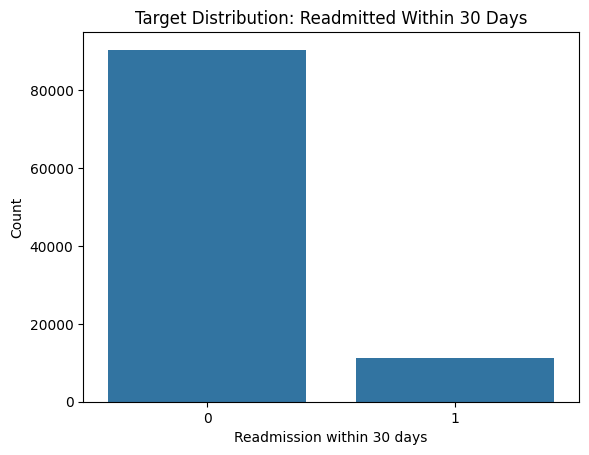

In [11]:
sns.countplot(x="target", data=df)
plt.title("Target Distribution: Readmitted Within 30 Days")
plt.xlabel("Readmission within 30 days")
plt.ylabel("Count")
plt.show()


In [12]:
columns_to_drop = [
    "encounter_id",        # unique encounter ID, no prediction value
    "patient_nbr",         # patient identifier, privacy issue
    "weight",              # too many missing values
    "payer_code",          # many missing / unknown values
    "medical_specialty",   # many missing and too many categories
    "readmitted"           # original target, already converted into target
]

df = df.drop(columns=columns_to_drop)

print(df.shape)
df.head()

(101766, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [14]:
df["gender"].value_counts()
df = df[df["gender"] != "Unknown/Invalid"]

df["gender"].value_counts()

,count
gender,
Female,54708
Male,47055


In [15]:
expired_ids = [11, 19, 20, 21]

df = df[~df["discharge_disposition_id"].isin(expired_ids)]

print(df.shape)

(100111, 45)


In [17]:
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}

discharge_map = {
    1: "Discharged to home",
    2: "Transferred to short term hospital",
    3: "Transferred to SNF",
    4: "Transferred to ICF",
    5: "Transferred to inpatient care institution",
    6: "Home with home health service",
    7: "Left AMA",
    8: "Home under care of IV provider",
    9: "Admitted as inpatient to this hospital",
    10: "Neonate discharged to another hospital",
    11: "Expired",
    12: "Still patient",
    13: "Hospice home",
    14: "Hospice medical facility",
    15: "Swing bed",
    16: "Outpatient services another institution",
    17: "Outpatient services this institution",
    18: "NULL",
    19: "Expired at home",
    20: "Expired in medical facility",
    21: "Expired unknown place",
    22: "Transferred to rehab",
    23: "Transferred to long term care hospital",
    24: "Transferred to nursing facility",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Federal health care facility",
    28: "Psychiatric hospital",
    29: "Critical Access Hospital",
    30: "Other health care institution"
}

admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from hospital",
    5: "Transfer from SNF",
    6: "Transfer from another health care facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from critical access hospital",
    11: "Normal Delivery",
    12: "Premature Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    15: "Not Available",
    17: "NULL",
    18: "Transfer from another home health agency",
    19: "Readmission to same home health agency",
    20: "Not Mapped",
    21: "Unknown/Invalid",
    22: "Transfer from hospital inpatient",
    23: "Born inside this hospital",
    24: "Born outside this hospital",
    25: "Transfer from ambulatory surgery center",
    26: "Transfer from hospice"
}

In [18]:
df["admission_type"] = df["admission_type_id"].map(admission_type_map)
df["discharge_disposition"] = df["discharge_disposition_id"].map(discharge_map)
df["admission_source"] = df["admission_source_id"].map(admission_source_map)

df[["admission_type_id", "admission_type",
    "discharge_disposition_id", "discharge_disposition",
    "admission_source_id", "admission_source"]].head()

,admission_type_id,admission_type,discharge_disposition_id,discharge_disposition,admission_source_id,admission_source
0,6,NULL,25,Not Mapped,1,Physician Referral
1,1,Emergency,1,Discharged to home,7,Emergency Room
2,1,Emergency,1,Discharged to home,7,Emergency Room
3,1,Emergency,1,Discharged to home,7,Emergency Room
4,1,Emergency,1,Discharged to home,7,Emergency Room


In [19]:
df = df.drop(columns=[
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
])

In [20]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
max_glu_serum,94887
A1Cresult,83235
race,2237
diag_3,1421
diag_2,358
diag_1,21
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
number_emergency,0


In [25]:
categorical_cols = df.select_dtypes(include=["object"]).columns

df[categorical_cols] = df[categorical_cols].fillna("Unknown")
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
df.isna().sum().sum()

np.int64(0)

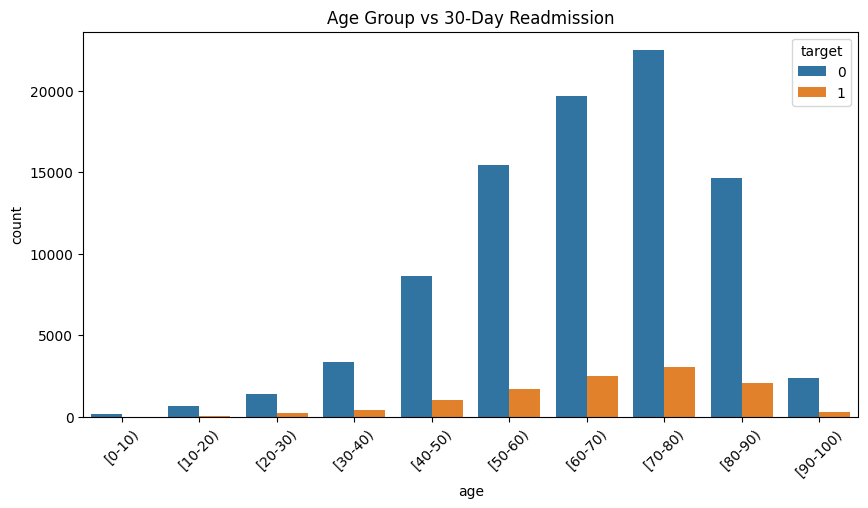

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(x="age", hue="target", data=df)
plt.title("Age Group vs 30-Day Readmission")
plt.xticks(rotation=45)
plt.show()

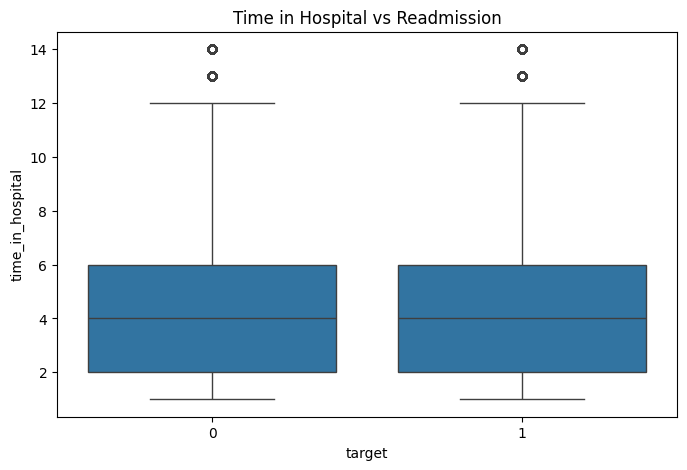

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="time_in_hospital", data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

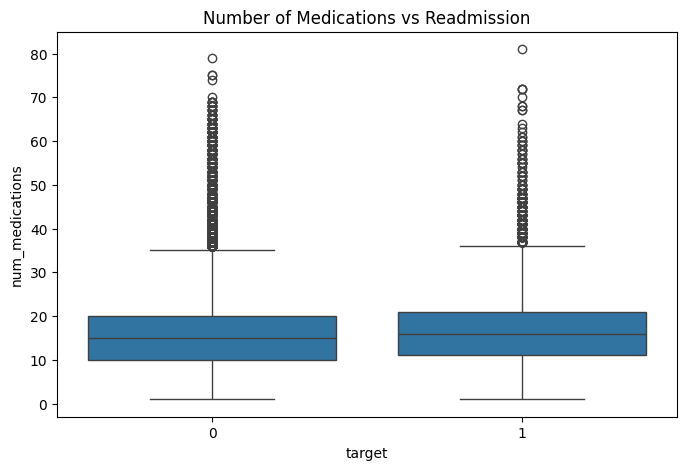

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="num_medications", data=df)
plt.title("Number of Medications vs Readmission")
plt.show()

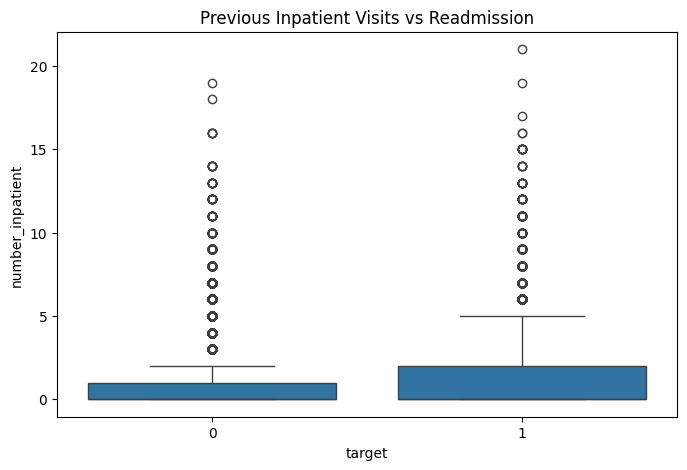

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="number_inpatient", data=df)
plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

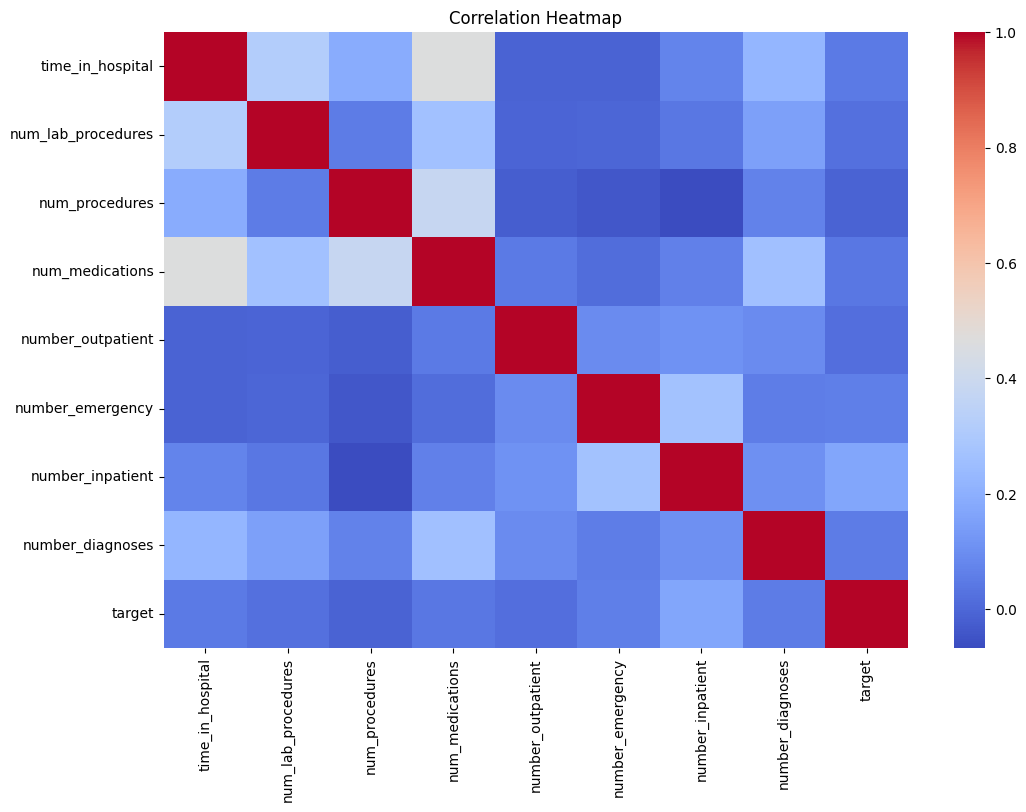

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [31]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100111, 44)
y shape: (100111,)


In [32]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical features: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type', 'discharge_disposition', 'admission_source']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80088, 44)
(20023, 44)


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [36]:
#Model 1: Logistic Regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'diag_1', 'diag_2', 'diag_3',
                                                   'max_glu_se...
                                                   'glimepiride',
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone', ...])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [37]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.659791240073915
Precision: 0.1789905273575569
Recall: 0.5574636723910171
F1 Score: 0.2709760273972603
ROC AUC: 0.6543972991352652

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17752
           1       0.18      0.56      0.27      2271

    accuracy                           0.66     20023
   macro avg       0.55      0.62      0.52     20023
weighted avg       0.84      0.66      0.72     20023



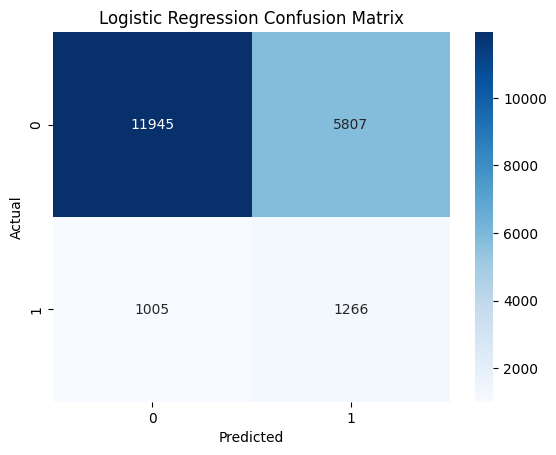

In [38]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
#Model 2: Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        max_depth=10
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'diag_1', 'diag_2', 'diag_3',
                                                   'max_glu_se...
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone', ...])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

In [40]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.6422114568246516
Precision: 0.1756595519024261
Recall: 0.5834434169969177
F1 Score: 0.2700224169553699
ROC AUC: 0.6611577705771123

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17752
           1       0.18      0.58      0.27      2271

    accuracy                           0.64     20023
   macro avg       0.55      0.62      0.52     20023
weighted avg       0.84      0.64      0.71     20023



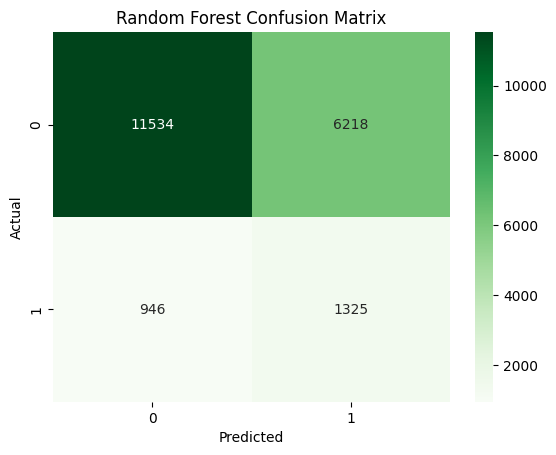

In [41]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.659791,0.178991,0.557464,0.270976,0.654397
1,Random Forest,0.642211,0.175660,0.583443,0.270022,0.661158


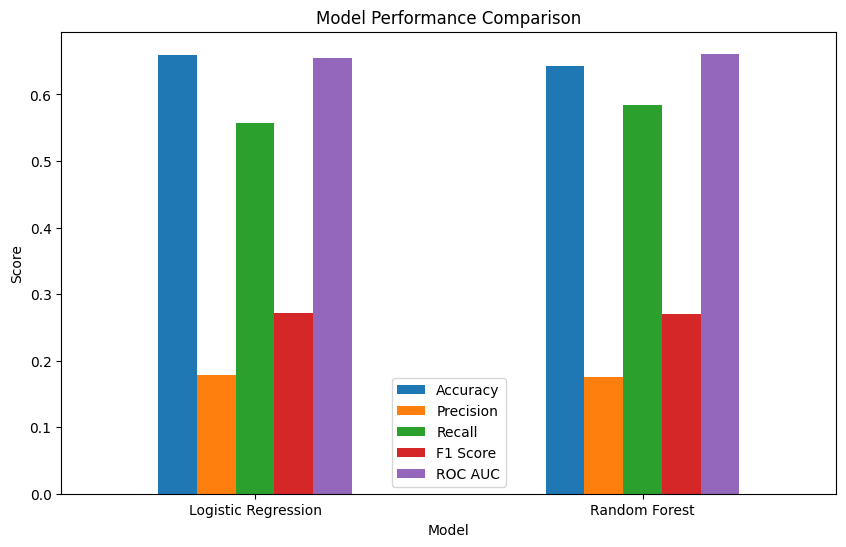

In [43]:
results.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [44]:
# Get feature names after one-hot encoding
cat_encoder = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

# Get feature importances
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
6,number_inpatient,0.134891
2299,discharge_disposition_Discharged to home,0.068189
2319,discharge_disposition_Transferred to rehab,0.038212
5,number_emergency,0.037080
7,number_diagnoses,0.032173
0,time_in_hospital,0.031447
3,num_medications,0.025836
2315,discharge_disposition_Transferred to SNF,0.025640
1,num_lab_procedures,0.020350
4,number_outpatient,0.018022


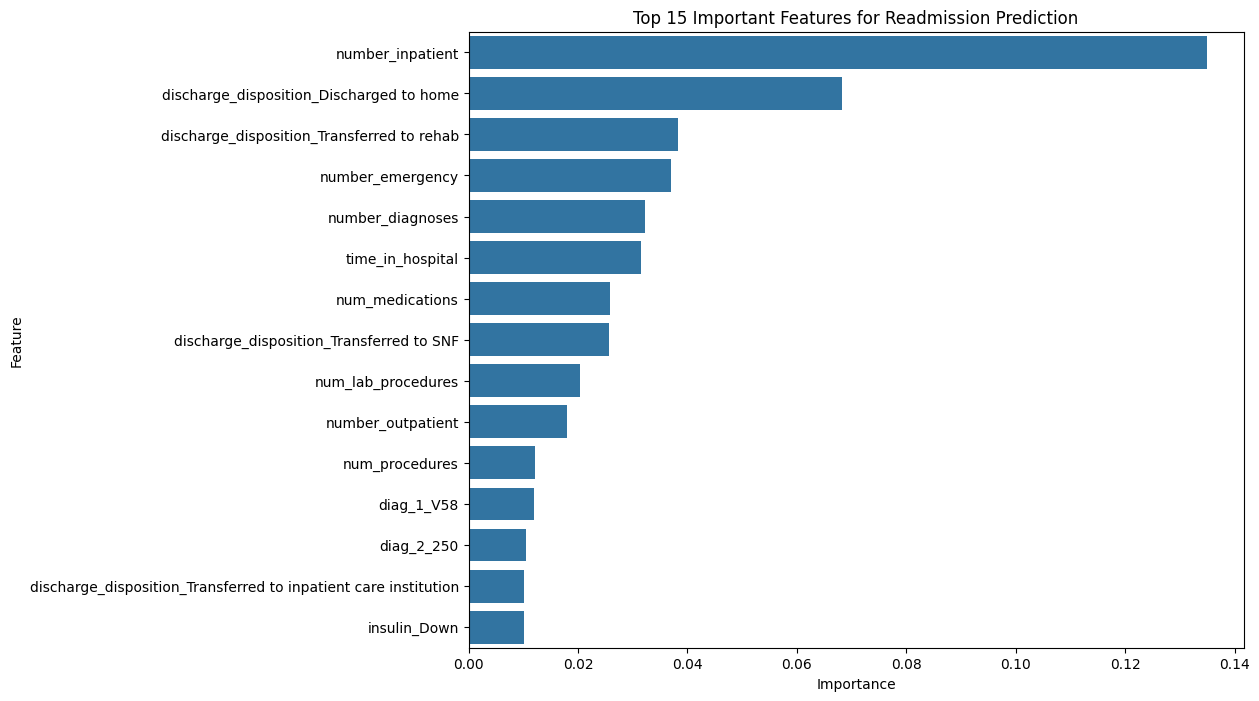

In [45]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(15)
)
plt.title("Top 15 Important Features for Readmission Prediction")
plt.show()

In [46]:
df.to_csv("diabetic_cleaned.csv", index=False)

print("Cleaned dataset saved as diabetic_cleaned.csv")

Cleaned dataset saved as diabetic_cleaned.csv


In [47]:
results.to_csv("model_results.csv", index=False)

print("Model results saved as model_results.csv")

Model results saved as model_results.csv


In [48]:
print("""
Conclusion:
This project used the diabetic hospital readmission dataset to predict whether a patient would be readmitted within 30 days.
The data was cleaned by removing identifiers, handling missing values, removing invalid gender rows, and excluding expired patients.
A binary target variable was created where 1 means readmitted within 30 days and 0 means not readmitted within 30 days.

Two models were trained: Logistic Regression and Random Forest.
Because the dataset is imbalanced, class_weight='balanced' was used.
The models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC AUC.
Recall and F1-score are especially important because hospitals should avoid missing patients who are actually at high risk of readmission.

Important features included previous inpatient visits, number of emergency visits, number of diagnoses, time in hospital, number of medications, and diabetes treatment-related variables.
""")


Conclusion:
This project used the diabetic hospital readmission dataset to predict whether a patient would be readmitted within 30 days.
The data was cleaned by removing identifiers, handling missing values, removing invalid gender rows, and excluding expired patients.
A binary target variable was created where 1 means readmitted within 30 days and 0 means not readmitted within 30 days.

Two models were trained: Logistic Regression and Random Forest.
Because the dataset is imbalanced, class_weight='balanced' was used.
The models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC AUC.
Recall and F1-score are especially important because hospitals should avoid missing patients who are actually at high risk of readmission.

Important features included previous inpatient visits, number of emergency visits, number of diagnoses, time in hospital, number of medications, and diabetes treatment-related variables.



| Metric        | Meaning                                                                    |
| ------------- | -------------------------------------------------------------------------- |
| **Accuracy**  | Overall correct predictions                                                |
| **Precision** | Out of patients predicted as readmitted, how many were actually readmitted |
| **Recall**    | Out of actually readmitted patients, how many the model successfully found |
| **F1 Score**  | Balance between precision and recall                                       |
| **ROC AUC**   | How well the model separates readmitted vs not-readmitted patients         |


1. **Logistic Regression**

Accuracy: 0.659
Precision: 0.179
Recall: 0.557
F1 Score: 0.271
ROC AUC: 0.654

This means:

It correctly predicts around 66% of all cases.
Precision is low: when it says “readmitted”, it is correct only around 18% of the time.
Recall is medium: it catches around 56% of real readmitted patients.
F1 score is low, meaning the model is not very strong overall.
ROC AUC is around 0.65, which means the model is better than random guessing, but not very strong.

2. **Random forest**


Accuracy: 0.642
Precision: 0.176
Recall: 0.583
F1 Score: 0.270
ROC AUC: 0.661
This means:

Accuracy is slightly lower than Logistic Regression.
Precision is almost the same, still low.
Recall is higher: it catches around 58% of real readmitted patients.
F1 score is almost the same.
ROC AUC is slightly better than Logistic Regression.


Which model is better?

For healthcare readmission prediction, Random Forest is slightly better because:

Recall: 0.583 > 0.557
ROC AUC: 0.661 > 0.654


In healthcare, recall is very important because we do not want to miss patients who are actually at risk.

So your conclusion can be:

Random Forest performed slightly better than Logistic Regression because it had higher recall and ROC AUC. Although both models had low precision, Random Forest was better at identifying patients who were actually readmitted within 30 days. Since the goal of this healthcare project is to detect high-risk patients, recall is more important than accuracy alone.